In [ ]:
import pandas as pd

df = pd.read_csv('D:\DATA_FULL_STACK\Data\offre-touristique-restaurants.csv', sep=';')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(3359, 49)
["Nom de l'offre touristique", 'Type de restaurant', 'Catégorie du restaurant', 'Adresse1', 'Adresse2', 'Adresse3', 'Code postal', 'Cedex', 'Bureau distributeur', 'Commune', 'Code Insee de la Commune', 'latitude', 'longitude', "Situation de l'offre", 'N° de téléphone mobile', 'N° de téléphone fixe', 'N° de fax', 'Adresse e-Mail', 'Url du site web', 'Url pour accéder à la vidéo', 'Type de plateforme/url', 'widget tripadvisor', 'Code Embed pour intégrer une video', 'Classement dans les guides restaurants', 'Label classement logis', 'Label tourisme handicap', 'Animal accepté: oui / non', 'Complément information animal accepté', 'Labels', "Service(s) proposé(s) sur l'équipement", 'Nombre max couverts', 'Nombre salles restaurant', 'Nombre max couverts en terrasse', 'Nombre salles de réunion', 'Nombre salles climatisées', "Présence de l'offre sur les grands itinéraires vélo", "Langue(s) parlée(s) à l'accueil", "Langue(s) parlée(s) à l'accueil.1", 'Nombre personnes min pour les gro

In [2]:
import pandas as pd
import sqlite3

df = pd.read_csv('D:\DATA_FULL_STACK\Data\offre-touristique-restaurants.csv', sep=';')

# Créer une base SQLite en mémoire
conn = sqlite3.connect('restaurants.db')
df.to_sql('restaurants', conn, if_exists='replace', index=False)

print("Base créée ✅")
print(f"{len(df)} restaurants chargés")

Base créée ✅
3359 restaurants chargés


In [3]:
def sql(query):
    return pd.read_sql_query(query, conn)

# 1. Nombre de restaurants par département
sql("""
SELECT Département, COUNT(*) as nb_restaurants
FROM restaurants
GROUP BY Département
ORDER BY nb_restaurants DESC
""")

,Département,nb_restaurants
0,Loire-Atlantique,1547
1,Maine-et-Loire,808
2,Sarthe,614
3,Mayenne,386
4,None,4


In [ ]:
# 2. Top 10 communes avec le plus de restaurants
sql("""
SELECT Commune, COUNT(*) as nb_restaurants
FROM restaurants
WHERE Commune IS NOT NULL
GROUP BY Commune
ORDER BY nb_restaurants DESC
LIMIT 10
""")

,Commune,nb_restaurants
0,LE MANS,169
1,ANGERS,152
2,SAINT-NAZAIRE,125
3,LAVAL,122
4,LA BAULE-ESCOUBLAC,108
5,SAUMUR,98
6,CHOLET,96
7,PORNIC,89
8,NANTES,89
9,GUERANDE,68


In [ ]:
# 3. Rang des communes par département (window function)
sql("""
SELECT 
    Département,
    Commune,
    COUNT(*) as nb_restaurants,
    RANK() OVER (PARTITION BY Département ORDER BY COUNT(*) DESC) as rang
FROM restaurants
WHERE Commune IS NOT NULL AND Département IS NOT NULL
GROUP BY Département, Commune
ORDER BY Département, rang
LIMIT 20
""")

,Département,Commune,nb_restaurants,rang
0,Loire-Atlantique,SAINT-NAZAIRE,125,1
1,Loire-Atlantique,LA BAULE-ESCOUBLAC,108,2
2,Loire-Atlantique,NANTES,89,3
3,Loire-Atlantique,PORNIC,87,4
4,Loire-Atlantique,GUERANDE,68,5
5,Loire-Atlantique,PORNICHET,58,6
6,Loire-Atlantique,SAINT-BREVIN-LES-PINS,56,7
7,Loire-Atlantique,LE POULIGUEN,50,8
8,Loire-Atlantique,ANCENIS-SAINT-GEREON,50,8
9,Loire-Atlantique,CHATEAUBRIANT,36,10


In [ ]:
# 4. CTE — Top 3 catégories par département
sql("""
WITH categorie_par_dept AS (
    SELECT 
        Département,
        "Catégorie du restaurant" as categorie,
        COUNT(*) as nb,
        RANK() OVER (
            PARTITION BY Département 
            ORDER BY COUNT(*) DESC
        ) as rang
    FROM restaurants
    WHERE Département IS NOT NULL 
    AND "Catégorie du restaurant" IS NOT NULL
    GROUP BY Département, "Catégorie du restaurant"
)
SELECT Département, categorie, nb, rang
FROM categorie_par_dept
WHERE rang <= 3
ORDER BY Département, rang
""")

,Département,categorie,nb,rang
0,Loire-Atlantique,Cuisine traditionnelle,428,1
1,Loire-Atlantique,Restauration rapide,180,2
2,Loire-Atlantique,Brasserie,172,3
3,Maine-et-Loire,Cuisine traditionnelle,257,1
4,Maine-et-Loire,Restaurant gastronomique - cuisine raffinée,93,2
5,Maine-et-Loire,Restauration rapide,79,3
6,Mayenne,Cuisine traditionnelle,156,1
7,Mayenne,Bistrot / bar à vin,41,2
8,Mayenne,Brasserie,28,3
9,Sarthe,Cuisine traditionnelle,247,1


In [ ]:
# 5. NTILE — Classement des communes en 4 quartiles
sql("""
SELECT 
    Commune,
    Département,
    COUNT(*) as nb_restaurants,
    NTILE(4) OVER (ORDER BY COUNT(*) DESC) as quartile
FROM restaurants
WHERE Commune IS NOT NULL AND Département IS NOT NULL
GROUP BY Commune, Département
ORDER BY nb_restaurants DESC
LIMIT 20
""")

,Commune,Département,nb_restaurants,quartile
0,LE MANS,Sarthe,169,1
1,ANGERS,Maine-et-Loire,152,1
2,SAINT-NAZAIRE,Loire-Atlantique,125,1
3,LAVAL,Mayenne,122,1
4,LA BAULE-ESCOUBLAC,Loire-Atlantique,108,1
5,SAUMUR,Maine-et-Loire,98,1
6,CHOLET,Maine-et-Loire,96,1
7,NANTES,Loire-Atlantique,89,1
8,PORNIC,Loire-Atlantique,87,1
9,GUERANDE,Loire-Atlantique,68,1


In [ ]:
# 6. LAG — Écart de restaurants entre communes consécutives
sql("""
WITH classement AS (
    SELECT 
        Commune,
        Département,
        COUNT(*) as nb_restaurants
    FROM restaurants
    WHERE Commune IS NOT NULL AND Département IS NOT NULL
    GROUP BY Commune, Département
    ORDER BY nb_restaurants DESC
    LIMIT 15
)
SELECT 
    Commune,
    Département,
    nb_restaurants,
    LAG(nb_restaurants) OVER (ORDER BY nb_restaurants DESC) as commune_precedente,
    nb_restaurants - LAG(nb_restaurants) OVER (ORDER BY nb_restaurants DESC) as ecart
FROM classement
ORDER BY nb_restaurants DESC
""")

,Commune,Département,nb_restaurants,commune_precedente,ecart
0,LE MANS,Sarthe,169,NaN,NaN
1,ANGERS,Maine-et-Loire,152,169.0,-17.0
2,SAINT-NAZAIRE,Loire-Atlantique,125,152.0,-27.0
3,LAVAL,Mayenne,122,125.0,-3.0
4,LA BAULE-ESCOUBLAC,Loire-Atlantique,108,122.0,-14.0
5,SAUMUR,Maine-et-Loire,98,108.0,-10.0
6,CHOLET,Maine-et-Loire,96,98.0,-2.0
7,NANTES,Loire-Atlantique,89,96.0,-7.0
8,PORNIC,Loire-Atlantique,87,89.0,-2.0
9,GUERANDE,Loire-Atlantique,68,87.0,-19.0


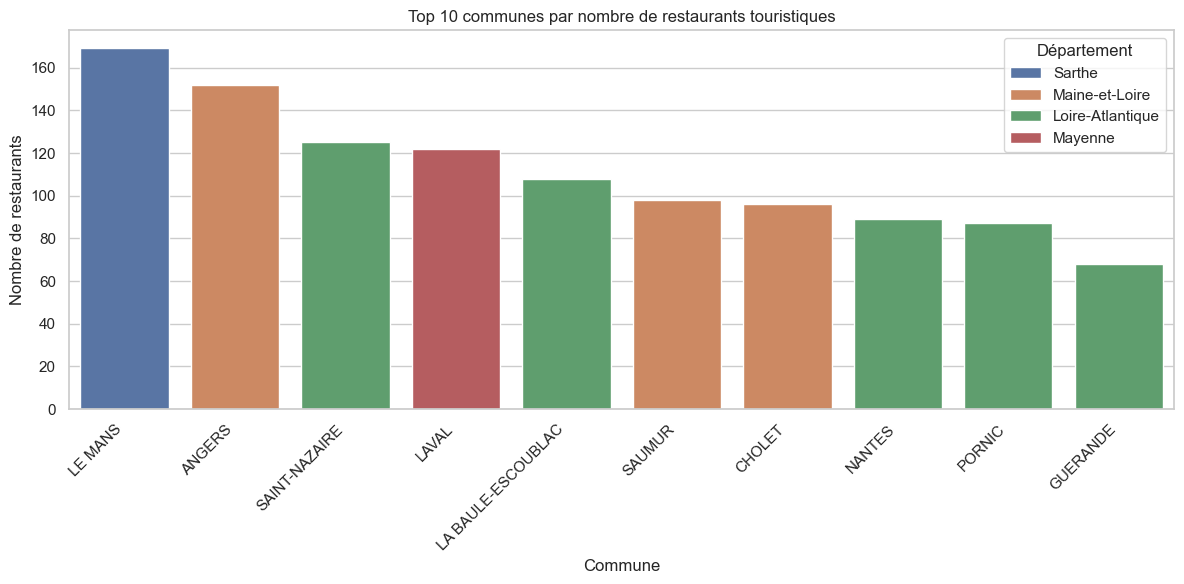

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Récupérer les données via SQL
top_communes = sql("""
SELECT Commune, Département, COUNT(*) as nb_restaurants
FROM restaurants
WHERE Commune IS NOT NULL AND Département IS NOT NULL
GROUP BY Commune, Département
ORDER BY nb_restaurants DESC
LIMIT 10
""")

# Barplot
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_communes, x='Commune', y='nb_restaurants', 
            hue='Département', ax=ax)
ax.set_title('Top 10 communes par nombre de restaurants touristiques')
ax.set_xlabel('Commune')
ax.set_ylabel('Nombre de restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_communes.png', dpi=150)
plt.show()

In [5]:
import plotly.express as px

# Récupérer coordonnées et données
df_carte = sql("""
SELECT 
    Commune,
    Département,
    COUNT(*) as nb_restaurants,
    AVG(latitude) as lat,
    AVG(longitude) as lon
FROM restaurants
WHERE latitude IS NOT NULL 
AND longitude IS NOT NULL
AND Commune IS NOT NULL
GROUP BY Commune, Département
""")

# Carte
fig = px.scatter_mapbox(
    df_carte,
    lat='lat',
    lon='lon',
    size='nb_restaurants',
    color='Département',
    hover_name='Commune',
    hover_data={'nb_restaurants': True, 'lat': False, 'lon': False},
    title='Répartition des restaurants touristiques en Pays de la Loire',
    mapbox_style='carto-positron',
    zoom=7,
    size_max=30
)
fig.write_html('carte_restaurants.html')
fig.show()

C:\Users\user\AppData\Local\Temp\ipykernel_2436\918192968.py:19: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(
